# Punto 1 Duque & Becerra Consulting 

## Imports y configuración

In [174]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel


sns.set_theme(style="whitegrid")

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import ParameterGrid
import numpy as np
from scipy import sparse
import shap
import joblib
import pickle

f2scorer =make_scorer(fbeta_score, beta=2, average='weighted')
SCORING_MAIN = f2scorer
SCORING_MAIN_NAME = "f2"
N_ITER_RANDOM_SEARCH = 20
RANDOM_STATE = 2003

## Exploración y preprocesamiento
La base de datos original se encuentra estructurada a nivel individual, donde cada observación corresponde a una persona dentro de un hogar. Sin embargo, el objetivo del ejercicio es predecir qué hogares deberían ser elegibles para recibir transferencias condicionadas. Por esta razón, el primer paso del análisis consiste en transformar la base individual en una base agregada a nivel de hogar. 

#### Tratamiento inicial de valores faltantes 
Antes de realizar la agregación, se llevó a cabo un proceso de limpieza de la base. En primer lugar, se identificaron variables con una proporción muy alta de valores faltantes. En aquellos casos donde la información disponible era insuficiente para una imputación confiable, dichas variables fueron eliminadas de la base para evitar introducir ruido o sesgos en el modelo. 

Para otras variables con un número moderado de valores faltantes, se aplicó imputación utilizando la media de la variable. Este procedimiento permite conservar observaciones sin distorsionar significativamente la distribución original de los datos. 

#### Transformación de la variable objetivo 
La variable original Target clasifica a los individuos en cuatro niveles de bienestar socioeconómico. Con el fin de alinear la variable con la decisión de política pública que se desea modelar, se construyó una variable binaria de elegibilidad: 

valor 1 para hogares pertenecientes a los niveles más vulnerables (categorías 1 y 2), 
valor 0 para hogares pertenecientes a los niveles relativamente menos vulnerables (categorías 3 y 4). 
Dado que la base inicial está a nivel individual, dentro de un mismo hogar pueden aparecer diferentes valores de Target. Para definir un único valor a nivel hogar, se utiliza la moda del target binario dentro del hogar, es decir, la categoría que aparece con mayor frecuencia entre sus miembros. 

#### Agregación de variables a nivel de hogar 
Una vez definida la variable objetivo, las variables explicativas se agregan utilizando el identificador de hogar (idhogar). La agregación de las variables se realiza principalmente mediante el promedio de los valores individuales dentro de cada hogar. 

Este procedimiento permite sintetizar la información individual y generar características representativas del hogar en su conjunto. En el caso de variables binarias, el promedio puede interpretarse como la proporción de miembros del hogar que presentan determinada característica. Para variables continuas, el promedio refleja el nivel medio de dicha característica dentro del hogar. 

El resultado de este proceso es una base de datos en la que cada observación corresponde a un hogar, con un conjunto de variables agregadas que capturan sus condiciones socioeconómicas y una variable objetivo binaria que indica si el hogar debería ser elegible para recibir transferencias. 

In [80]:
df_raw= pd.read_csv("/Users/juanfelipe/Documents/Datos_Taller1/Punto1/train.csv")

In [81]:
df_raw.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target
0,ID_279628684,190000.0,0,3,0,1,1,0,NaN,0,...,100,1849,1,100,0,1.000000,0.0,100.0,1849,4
1,ID_f29eb3ddd,135000.0,0,4,0,1,1,1,1.0,0,...,144,4489,1,144,0,1.000000,64.0,144.0,4489,4
2,ID_d671db89c,180000.0,0,5,0,1,1,1,1.0,0,...,81,289,16,121,4,1.777778,1.0,121.0,289,4
3,ID_d56d6f5f5,180000.0,0,5,0,1,1,1,1.0,0,...,121,1369,16,121,4,1.777778,1.0,121.0,1369,4
4,ID_ec05b1a7b,180000.0,0,5,0,1,1,1,1.0,0,...,121,1444,16,121,4,1.777778,1.0,121.0,1444,4


In [82]:
df_ed = df_raw.replace("no", 99)
df_ed = df_ed.replace("yes", 1)
df_ed.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target
0,ID_279628684,190000.0,0,3,0,1,1,0,NaN,0,...,100,1849,1,100,0,1.000000,0.0,100.0,1849,4
1,ID_f29eb3ddd,135000.0,0,4,0,1,1,1,1.0,0,...,144,4489,1,144,0,1.000000,64.0,144.0,4489,4
2,ID_d671db89c,180000.0,0,5,0,1,1,1,1.0,0,...,81,289,16,121,4,1.777778,1.0,121.0,289,4
3,ID_d56d6f5f5,180000.0,0,5,0,1,1,1,1.0,0,...,121,1369,16,121,4,1.777778,1.0,121.0,1369,4
4,ID_ec05b1a7b,180000.0,0,5,0,1,1,1,1.0,0,...,121,1444,16,121,4,1.777778,1.0,121.0,1444,4


In [83]:
string_cols = df_ed.select_dtypes(include=['object']).columns.tolist()
print(string_cols)
print(df_raw[string_cols].dtypes)



['Id', 'idhogar', 'dependency', 'edjefe', 'edjefa']
Id            str
idhogar       str
dependency    str
edjefe        str
edjefa        str
dtype: object


/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/1724332602.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_ed.select_dtypes(include=['object']).columns.tolist()


In [84]:
df_ed['dependency']=df_ed['dependency'].astype(float)
df_ed['edjefe']=df_ed['edjefe'].astype(float)
df_ed['edjefa']=df_ed['edjefa'].astype(float)


Verificamos missing values para ver como accionar

In [85]:
missing_pct = df_ed.isna().mean().sort_values(ascending=False) * 100

missing_pct = missing_pct[missing_pct > 0]
missing_pct



rez_esc      82.830110
v18q1        76.874913
v2a1         72.547655
SQBmeaned     0.069570
meaneduc      0.069570
dtype: float64

cambiamos que si v18q1 es NaN es = 0 tablets

In [86]:
df_ed['v18q1'] = df_ed['v18q1'].fillna(0)
df_ed.head()

,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target
0,ID_279628684,190000.0,0,3,0,1,1,0,0.0,0,...,100,1849,1,100,0,1.000000,0.0,100.0,1849,4
1,ID_f29eb3ddd,135000.0,0,4,0,1,1,1,1.0,0,...,144,4489,1,144,0,1.000000,64.0,144.0,4489,4
2,ID_d671db89c,180000.0,0,5,0,1,1,1,1.0,0,...,81,289,16,121,4,1.777778,1.0,121.0,289,4
3,ID_d56d6f5f5,180000.0,0,5,0,1,1,1,1.0,0,...,121,1369,16,121,4,1.777778,1.0,121.0,1369,4
4,ID_ec05b1a7b,180000.0,0,5,0,1,1,1,1.0,0,...,121,1444,16,121,4,1.777778,1.0,121.0,1444,4


In [87]:
df_ed['v2a1_reg'] = df_ed['v2a1'].notna().astype(int)
df_ed[['v2a1', 'v2a1_reg']].head()

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/3507588055.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ed['v2a1_reg'] = df_ed['v2a1'].notna().astype(int)


,v2a1,v2a1_reg
0,190000.0,1
1,135000.0,1
2,180000.0,1
3,180000.0,1
4,180000.0,1


In [88]:
df_ed=df_ed.drop('v2a1', axis=1)
df_ed.head()

,Id,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target,v2a1_reg
0,ID_279628684,0,3,0,1,1,0,0.0,0,1,...,1849,1,100,0,1.000000,0.0,100.0,1849,4,1
1,ID_f29eb3ddd,0,4,0,1,1,1,1.0,0,1,...,4489,1,144,0,1.000000,64.0,144.0,4489,4,1
2,ID_d671db89c,0,5,0,1,1,1,1.0,0,2,...,289,16,121,4,1.777778,1.0,121.0,289,4,1
3,ID_d56d6f5f5,0,5,0,1,1,1,1.0,0,2,...,1369,16,121,4,1.777778,1.0,121.0,1369,4,1
4,ID_ec05b1a7b,0,5,0,1,1,1,1.0,0,2,...,1444,16,121,4,1.777778,1.0,121.0,1444,4,1


In [89]:
df_ed['rezago'] = df_ed['rez_esc'].notna().astype(int)
df_ed[['rez_esc', 'rezago']].head()

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/3619481293.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ed['rezago'] = df_ed['rez_esc'].notna().astype(int)


,rez_esc,rezago
0,NaN,0
1,NaN,0
2,1.0,1
3,NaN,0
4,NaN,0


In [90]:
# crear columna 'gran rezago' en X_ed: 1 si rez_esc >= 3, else 0
df_ed['gran_rezago'] = (df_ed['rez_esc'] >= 3).astype(int)
df_ed[['rez_esc', 'gran_rezago']].head()

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/1399972834.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_ed['gran_rezago'] = (df_ed['rez_esc'] >= 3).astype(int)


,rez_esc,gran_rezago
0,NaN,0
1,NaN,0
2,1.0,0
3,NaN,0
4,NaN,0


In [91]:
df_ed=df_ed.drop('rez_esc', axis=1)
df_ed.head()

,Id,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target,v2a1_reg,rezago,gran_rezago
0,ID_279628684,0,3,0,1,1,0,0.0,0,1,...,100,0,1.000000,0.0,100.0,1849,4,1,0,0
1,ID_f29eb3ddd,0,4,0,1,1,1,1.0,0,1,...,144,0,1.000000,64.0,144.0,4489,4,1,0,0
2,ID_d671db89c,0,5,0,1,1,1,1.0,0,2,...,121,4,1.777778,1.0,121.0,289,4,1,1,0
3,ID_d56d6f5f5,0,5,0,1,1,1,1.0,0,2,...,121,4,1.777778,1.0,121.0,1369,4,1,0,0
4,ID_ec05b1a7b,0,5,0,1,1,1,1.0,0,2,...,121,4,1.777778,1.0,121.0,1444,4,1,0,0


In [92]:
df_indifinal = df_ed.dropna()
df_indifinal.shape, df_ed.shape

((7182, 144), (7187, 144))

In [93]:
df_ed['meaneduc'].sort_values(ascending=True).head(10)

6811    0.0
4106    0.0
2536    0.0
7130    0.0
2903    0.0
941     0.0
942     0.0
6598    0.0
3894    0.0
6597    0.0
Name: meaneduc, dtype: float64

In [94]:
missing_pct = df_indifinal.isna().mean().sort_values(ascending=False) * 100

missing_pct = missing_pct[missing_pct > 0]
missing_pct



Series([], dtype: float64)

In [95]:


data = df_indifinal.dropna()

print("Después:", data.shape)

X_prev = data.drop(columns='Target')
y_prev = data['Target']

Después: (7182, 144)


In [96]:
X_prev.head()

,Id,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg,rezago,gran_rezago
0,ID_279628684,0,3,0,1,1,0,0.0,0,1,...,1,100,0,1.000000,0.0,100.0,1849,1,0,0
1,ID_f29eb3ddd,0,4,0,1,1,1,1.0,0,1,...,1,144,0,1.000000,64.0,144.0,4489,1,0,0
2,ID_d671db89c,0,5,0,1,1,1,1.0,0,2,...,16,121,4,1.777778,1.0,121.0,289,1,1,0
3,ID_d56d6f5f5,0,5,0,1,1,1,1.0,0,2,...,16,121,4,1.777778,1.0,121.0,1369,1,0,0
4,ID_ec05b1a7b,0,5,0,1,1,1,1.0,0,2,...,16,121,4,1.777778,1.0,121.0,1444,1,0,0


In [97]:
y_prev.head()

0    4
1    4
2    4
3    4
4    4
Name: Target, dtype: int64

In [98]:

y_prev = y_prev.apply(lambda x: 1 if x <= 2 else 0)


In [99]:
data = pd.concat([X_prev, y_prev], axis=1)

data = data.drop('Id', axis=1)

data_hogar = (
    data
    .groupby("idhogar")
    .agg({
        **{col: "mean" for col in data.columns if col not in ["idhogar", "Target"]},
        "Target": lambda x: x.mode().iloc[0] if not x.mode().empty else None
    })
    .reset_index()
)


/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/328169545.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


In [100]:
data_hogar.head()

,idhogar,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,...,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,v2a1_reg,rezago,gran_rezago,Target
0,001ff74ca,0.0,6.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.250000,1.0,256.00,722.00,0.0,0.0,0.0,0
1,003123ec2,0.0,3.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,...,36.0,4.0,4.000000,1.0,42.25,278.75,0.0,0.0,0.0,1
2,004616164,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,...,9.0,1.0,0.444444,1.0,9.00,1378.00,0.0,0.5,0.0,1
3,004983866,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.000000,1.0,64.00,1868.50,0.0,0.5,0.0,0
4,006b64543,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.000000,0.0,49.00,1970.00,0.0,0.0,0.0,0


In [101]:
data_hogar['edjefe']= data_hogar['edjefe'].replace(99, np.nan)
data_hogar['edjefa']= data_hogar['edjefa'].replace(99, np.nan)
data_hogar['edjef']= data_hogar[['edjefe', 'edjefa']].mean(axis=1)

/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/2583590229.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_hogar['edjef']= data_hogar[['edjefe', 'edjefa']].mean(axis=1)


In [102]:
data_hogar['edjef'] = data_hogar['edjef'].fillna(0)

In [103]:
data_hogar = data_hogar.drop(columns=['edjefe', 'edjefa'])

## Feature Engineering

En total se construyeron 6 variables adicionales a partir de la información agregada a nivel hogar. 

Una de las variables construidas es hacinamiento crítico, definida como un indicador binario que toma valor 1 cuando el nivel de hacinamiento del hogar supera un umbral crítico. Esta variable busca capturar situaciones donde el número de personas por habitación es excesivo, lo cual constituye una dimensión importante de pobreza multidimensional, ya que refleja restricciones severas en condiciones habitacionales y calidad de vida. 

También se construyó una variable de dependencia ajustada, que aproxima la carga económica dentro del hogar. Esta variable sintetiza la relación entre miembros dependientes y miembros potencialmente activos del hogar, permitiendo identificar hogares donde pocos individuos deben sostener a un número elevado de dependientes. Desde la perspectiva de política social, hogares con alta dependencia suelen presentar mayor vulnerabilidad económica y mayor probabilidad de requerir transferencias. 

Otra variable relevante es un índice de calidad de vivienda, que combina diferentes características estructurales del hogar relacionadas con materiales de construcción, infraestructura y servicios básicos. Este tipo de indicadores suele utilizarse en mediciones de pobreza estructural, ya que permite capturar privaciones que no necesariamente se reflejan directamente en variables de ingreso. 

Adicionalmente se creó una variable de densidad tecnológica, que mide el acceso del hogar a activos tecnológicos como computadoras o tablets. Este tipo de activos se encuentra altamente correlacionado con el capital humano del hogar, oportunidades educativas y nivel socioeconómico general. 

También se construyó una variable dedicada a describir la vulnerabilidad estructural del hogar, usando hacinamiento, dependencia y educación como base estructural de la vulnerabilidad. Esta nueva métrica se fundamenta en identificar carencias que no cuentan con una solución simple y condicionan las capacidades de los hogares a futuro.  

Finalmente se construyó una variable que captura la proporción de mujeres dentro del hogar, con el objetivo de caracterizar la estructura demográfica del hogar. Este tipo de variables puede capturar patrones asociados a hogares monoparentales o estructuras familiares específicas que pueden estar correlacionadas con niveles diferenciados de vulnerabilidad. 

Estas variables adicionales permiten enriquecer la representación socioeconómica de los hogares y capturar dimensiones de pobreza estructural que no se reflejan completamente en las variables originales del dataset. 

In [104]:
data_hogar['hacinamiento_critico'] = (data_hogar['overcrowding'] > 3).astype(int) #Hacinamiento
data_hogar['dependencia_ajustada'] = ((data_hogar['hogar_nin'] + data_hogar['hogar_mayor']) /  (data_hogar['hogar_adul'] + 1))
data_hogar['calidad_vivienda'] = (data_hogar['epared3'] + data_hogar['etecho3'] + data_hogar['eviv3']) #Calidad de la casa
data_hogar['densidad_tecnologica'] = (data_hogar['computer'] + (data_hogar['mobilephone'] * data_hogar['qmobilephone'].clip(upper=3))) #Densidad tecnológica 
data_hogar['vulnerabilidad_estructural'] = ( data_hogar['overcrowding'] * data_hogar['dependencia_ajustada'] /  (data_hogar['meaneduc'] + 1)) #Vulnerabilidad estructural
data_hogar['prop_mujeres'] = ( data_hogar['female'] / (data_hogar['hhsize'] + 1)) #Proporción de mujeres


/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/595490964.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_hogar['hacinamiento_critico'] = (data_hogar['overcrowding'] > 3).astype(int) #Hacinamiento
/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykernel_41602/595490964.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_hogar['dependencia_ajustada'] = ((data_hogar['hogar_nin'] + data_hogar['hogar_mayor']) /  (data_hogar['hogar_adul'] + 1))
/var/folders/m9/8glbgjx57n9ft9qzy1pc32k40000gn/T/ipykerne

## Elección de la metrica de elección
En el contexto del programa de transferencias condicionadas, existen dos posibles errores de clasificación. El primero corresponde a los falsos positivos, que ocurren cuando un hogar es clasificado como elegible para recibir transferencias aun cuando no debería recibirlas. El segundo corresponde a los falsos negativos, que se presentan cuando un hogar vulnerable no es identificado como beneficiario del programa. 

Desde la perspectiva de política pública, estos errores no tienen el mismo costo. Un falso positivo implica un gasto adicional para el programa, asociado al costo de la transferencia y a los costos administrativos de verificación. Sin embargo, un falso negativo implica que un hogar vulnerable queda excluido de un programa diseñado precisamente para apoyar a la población en mayor situación de pobreza. 

De acuerdo con la estructura de costos planteada en el enunciado, donde se establece que el costo de un falso positivo es de 1350 mientras que el de un falso negativo es de 3800, el costo económico de un falso negativo es considerablemente mayor que el de un falso positivo. Esto refleja no solo los costos administrativos adicionales, sino también los costos sociales asociados a la exclusión de hogares vulnerables del programa. Adicionalmente, se debe reconocer la existencia de otros costos intangibles de los falsos negativos, tales como la perdida de legitimidad de un programa que puede ocasionar que los hogares vulnerables opongan resistencia frente a intentos de intervención estatales. 

Por esta razón, la evaluación del modelo se basa principalmente en el F2-score, una métrica que asigna mayor peso al recall de hogares vulnerables que a la precisión. Esta métrica penaliza de manera más severa los falsos negativos, lo cual es consistente con el objetivo de minimizar la exclusión de hogares vulnerables. Si bien se reportan también métricas tradicionales como accuracy, precisión y recall, el F2-score será utilizado como criterio principal para comparar modelos y seleccionar la especificación final. 

## Modelamiento
Para identificar el modelo con mejor desempeño predictivo se estimaron múltiples algoritmos de clasificación utilizando la base agregada a nivel de hogar. El proceso de modelamiento incluyó tanto modelos lineales como modelos basados en árboles y métodos de ensamble. 

Inicialmente se estimaron tres modelos base: regresión logística, máquinas de soporte vectorial (SVM) y k-vecinos más cercanos (KNN). Estos modelos permiten establecer una línea base de desempeño utilizando diferentes tipos de fronteras de decisión. 

Los resultados iniciales muestran que la regresión logística presenta el mejor desempeño en términos de F2-score entre los modelos base. En particular, el modelo logístico alcanza: 

Accuracy: 0.779 
Precision: 0.592 
Recall: 0.398 
F2-score: 0.426 
ROC-AUC: 0.772 
Estos resultados indican que, aunque el modelo logra identificar correctamente una proporción razonable de hogares vulnerables, todavía existe un número importante de falsos negativos. 

Posteriormente se realizó un proceso de ajuste de hiperparámetros mediante validación cruzada para optimizar el desempeño de los modelos. Después del tuning, la regresión logística continúa mostrando el mejor desempeño entre los modelos evaluados, con un F2-score de aproximadamente 0.435 en el conjunto de prueba. 

Adicionalmente se evaluaron modelos basados en árboles y métodos de ensamble, incluyendo árboles CART, random forest y XGBoost. Los resultados base de estos modelos muestran el siguiente desempeño: (Visible en el codigo)

Si bien algunos de estos modelos alcanzan niveles más altos de accuracy o precisión, el recall tiende a ser menor, lo cual reduce el F2-score. 

Tras realizar un proceso adicional de tuning sobre estos modelos, el modelo de Random Forest ajustado alcanza un F2-score cercano a 0.7, con un threshold de 0.14, convirtiéndose en el modelo con mejor desempeño final según la métrica seleccionada. Este resultado sugiere que el árbol de decisión logra capturar interacciones relevantes entre variables que no son completamente capturadas por los modelos lineales. Por lo que se definió Random Forest como el modelo a utilizar. 


In [105]:
data_hogar = data_hogar.drop(['idhogar'], axis=1)

In [106]:
X = data_hogar.drop(columns=["Target"])
y = data_hogar["Target"]

In [107]:
y

0       0
1       1
2       1
3       0
4       0
       ..
2233    0
2234    0
2235    0
2236    1
2237    0
Name: Target, Length: 2238, dtype: int64

Aqui ya debemos de tener todo para empezar a correr modelos

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1790
Test size: 448


In [109]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [110]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

alphas = np.logspace(-4, 2, 30, 20, 7)
l1_ratios = [0.1, 0.5, 0.9, 1.0, 0.01, 0.001, 0.0001]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=cv,
    max_iter=20000,
    n_jobs=-1,
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", elastic_cv),
    ]
)

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [111]:
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

In [112]:
def evaluate_thresholds(y_true, y_prob, thresholds, c_fp=1, c_fn=2):
    """
    Evalúa métricas y costo total para múltiples umbrales de clasificación.
    
    Args:
        y_true: etiquetas reales (0/1)
        y_prob: probabilidades predichas para la clase positiva
        thresholds: lista de umbrales a evaluar
        c_fp: costo unitario de falsos positivos (default=1)
        c_fn: costo unitario de falsos negativos (default=2)
    
    Returns:
        DataFrame con tn, fp, fn, tp, precision, recall, f1 y costo_total por umbral
    """
    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
        rows.append({
            "threshold": t,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "precision": precision_score(y_true, y_pred_t, zero_division=0),
            "recall": recall_score(y_true, y_pred_t, zero_division=0),
            "f2": fbeta_score(y_true, y_pred_t, beta=2, zero_division=0),
            "cost_total": c_fp * fp + c_fn * fn,
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

In [113]:
def fit_and_eval(name, estimator, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    metrics_dict = evaluate_model(y_test, y_pred, y_prob)
    metrics_dict["model"] = name
    return pipe, metrics_dict

In [114]:
from sklearn.linear_model import LogisticRegressionCV
models = {
    "logit": LogisticRegression(max_iter=20000, class_weight=None),
    "knn": KNeighborsClassifier(),
    "svm": SVC(probability=True),
}

base_results = []
base_confusions = {}
fitted_base_models = {}

for model_name, model_obj in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model_obj),
    ])
    pipe.fit(X_train, y_train)

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics_dict = evaluate_model(y_test, y_pred, y_prob)
    metrics_dict["model"] = model_name
    base_results.append(metrics_dict)

    cm = confusion_matrix(y_test, y_pred)
    base_confusions[model_name] = cm
    fitted_base_models[model_name] = pipe

base_results_df = pd.DataFrame(base_results).sort_values("f2", ascending=False).reset_index(drop=True)
print("Resultados base (ordenados por F2):")
display(base_results_df)


Resultados base (ordenados por F2):


,accuracy,precision,recall,f2,roc_auc,model
0,0.776786,0.578313,0.424779,0.448598,0.766979,logit
1,0.752232,0.520000,0.230088,0.258964,0.741540,svm
2,0.743304,0.480000,0.212389,0.239044,0.686290,knn


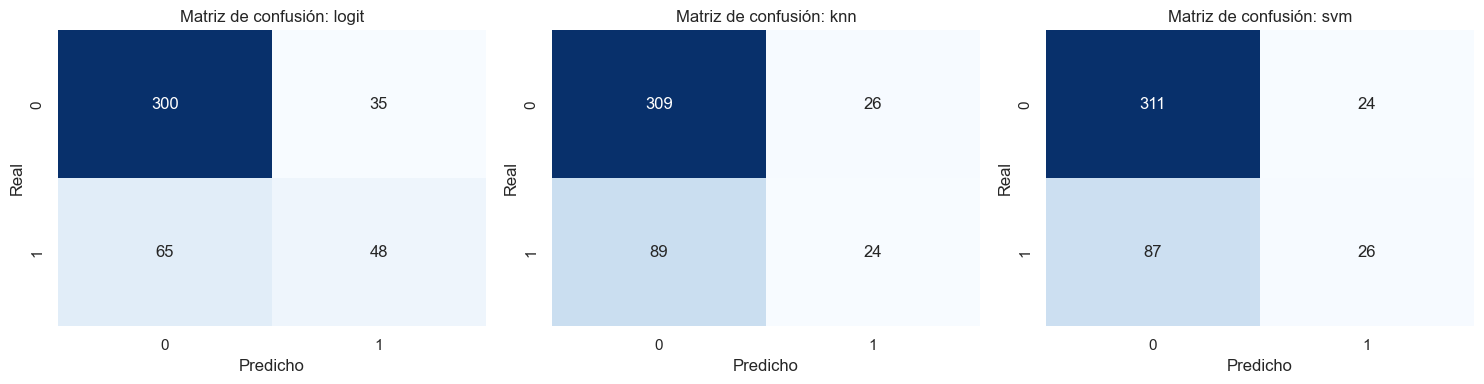

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model_name in zip(axes, ["logit", "knn", "svm"]):
    cm = base_confusions[model_name]
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de confusión: {model_name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

for model_name in ["logit", "knn", "svm"]:
    cm_sum = base_confusions[model_name].sum()
    assert cm_sum == len(y_test), f"La matriz de {model_name} no suma len(y_test)."

In [116]:
y.describe()

count    2238.000000
mean        0.226542
std         0.418687
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Target, dtype: float64

In [117]:
param_grids = {
    "logit": {
        "model__C": [0.1, 1.0, 10.0],               
        "model__penalty": ["l2"],                   # ridge
    },
    "knn": {
        "model__n_neighbors": [5, 11, 21],          
        "model__weights": ["uniform", "distance"],  
        "model__p": [1, 2],                         
    },
    "svm": [
        {
            "model__kernel": ["linear"],
            "model__C": [0.5, 1.0, 5.0],
        },
        {
            "model__kernel": ["rbf"],
            "model__C": [0.5, 1.0, 5.0],
            "model__gamma": ["scale", 0.1, 0.01],
        },
    ],
}


In [118]:
cv_results = []
best_estimators = {}

for model_name, model_obj in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model_obj),
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[model_name],
        scoring=SCORING_MAIN,
        cv=5,
        n_jobs=-1,
        refit=True,
        verbose=0,
    )

    grid.fit(X_train, y_train)

    best_pipe = grid.best_estimator_
    y_prob = best_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    metrics_dict = evaluate_model(y_test, y_pred, y_prob)
    metrics_dict.update({
        "model": model_name,
        "best_cv_f2": grid.best_score_,
        "best_params": grid.best_params_,
    })

    cv_results.append(metrics_dict)
    best_estimators[model_name] = best_pipe

cv_results_df = pd.DataFrame(cv_results).sort_values("f2", ascending=False).reset_index(drop=True)
print("Resultados tuned (ordenados por F2 en test):")
display(cv_results_df[["model", "best_cv_f2", "accuracy", "precision", "recall", "f2", "roc_auc", "best_params"]])


/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-package

Resultados tuned (ordenados por F2 en test):


,model,best_cv_f2,accuracy,precision,recall,f2,roc_auc,best_params
0,logit,0.794938,0.779018,0.592105,0.398230,0.426136,0.771946,"{'model__C': 0.1, 'model__penalty': 'l2'}"
1,svm,0.792389,0.754464,0.530612,0.230088,0.259481,0.759451,"{'model__C': 0.5, 'model__kernel': 'linear'}"
2,knn,0.785225,0.761161,0.607143,0.150442,0.177083,0.750020,"{'model__n_neighbors': 21, 'model__p': 1, 'mod..."


In [119]:
best_row = cv_results_df.iloc[0]
best_model_name = best_row["model"]
best_model = best_estimators[best_model_name]

print("Mejor modelo según F2 en test:", best_model_name)
print("Mejores hiperparámetros:")
print(best_row["best_params"])
print("Métricas test del mejor modelo:")
display(best_row[["accuracy", "precision", "recall", "f2", "roc_auc"]].to_frame("value"))

if best_row["precision"] > best_row["recall"]:
    comment = "Tradeoff observado: el modelo está más conservador (mayor precision que recall)."
elif best_row["precision"] < best_row["recall"]:
    comment = "Tradeoff observado: el modelo está más agresivo (mayor recall que precision)."
else:
    comment = "Tradeoff observado: precision y recall están balanceados."

print(comment)

Mejor modelo según F2 en test: logit
Mejores hiperparámetros:
{'model__C': 0.1, 'model__penalty': 'l2'}
Métricas test del mejor modelo:


,value
accuracy,0.779018
precision,0.592105
recall,0.39823
f2,0.426136
roc_auc,0.771946


Tradeoff observado: el modelo está más conservador (mayor precision que recall).


In [120]:
best_prob_test = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.0, 1, 0.01).tolist()
C_FP = 1350
C_FN = 3800

threshold_table = evaluate_thresholds(
    y_true=y_test,
    y_prob=best_prob_test,
    thresholds=thresholds,
    c_fp=C_FP,
    c_fn=C_FN,
)

print("Tabla de umbral vs métricas/costo:")
display(threshold_table)

best_threshold_row = threshold_table.loc[threshold_table["cost_total"].idxmin()]
print(
    f"Umbral de menor costo: {best_threshold_row['threshold']} "
    f"(Costo={best_threshold_row['cost_total']:.0f}, FP={best_threshold_row['fp']:.0f}, FN={best_threshold_row['fn']:.0f})"
)


Tabla de umbral vs métricas/costo:


,threshold,tn,fp,fn,tp,precision,recall,f2,cost_total
0,0.00,0,335,0,113,0.252232,1.000000,0.627778,452250
1,0.01,39,296,0,113,0.276284,1.000000,0.656214,399600
2,0.02,73,262,2,111,0.297587,0.982301,0.672727,361300
3,0.03,86,249,5,108,0.302521,0.955752,0.667491,355150
4,0.04,106,229,7,106,0.316418,0.938053,0.673443,335750
...,...,...,...,...,...,...,...,...,...
95,0.95,335,0,109,4,1.000000,0.035398,0.043860,414200
96,0.96,335,0,109,4,1.000000,0.035398,0.043860,414200
97,0.97,335,0,109,4,1.000000,0.035398,0.043860,414200
98,0.98,335,0,110,3,1.000000,0.026549,0.032967,418000


Umbral de menor costo: 0.23 (Costo=251050, FP=79, FN=38)


In [121]:
threshold_table.sort_values("cost_total").reset_index(drop=False)

,index,threshold,tn,fp,fn,tp,precision,recall,f2,cost_total
0,23,0.23,256,79,38,75,0.487013,0.663717,0.618812,251050
1,24,0.24,262,73,41,72,0.496552,0.637168,0.603015,254350
2,25,0.25,265,70,43,70,0.500000,0.619469,0.591216,257900
3,18,0.18,227,108,30,83,0.434555,0.734513,0.645412,259800
4,17,0.17,224,111,29,84,0.430769,0.743363,0.649150,260050
...,...,...,...,...,...,...,...,...,...,...
95,97,0.97,335,0,109,4,1.000000,0.035398,0.043860,414200
96,96,0.96,335,0,109,4,1.000000,0.035398,0.043860,414200
97,98,0.98,335,0,110,3,1.000000,0.026549,0.032967,418000
98,99,0.99,335,0,112,1,1.000000,0.008850,0.011038,425600


In [122]:
X.head()


,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,r4h3,...,v2a1_reg,rezago,gran_rezago,edjef,hacinamiento_critico,dependencia_ajustada,calidad_vivienda,densidad_tecnologica,vulnerabilidad_estructural,prop_mujeres
0,0.0,6.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,16.0,0,0.500000,3.0,1.0,0.014706,0.333333
1,0.0,3.0,0.0,1.0,1.0,0.0,0.0,2.0,1.0,3.0,...,0.0,0.0,0.0,6.0,0,0.666667,1.0,2.0,0.177778,0.050000
2,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,...,0.0,0.5,0.0,3.0,0,0.500000,0.0,2.0,0.083333,0.000000
3,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.5,0.0,8.0,0,0.500000,0.0,2.0,0.055556,0.166667
4,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,3.0,0,0.000000,1.0,2.0,0.000000,0.166667


In [123]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)



In [124]:
param_grid = {
    "model__n_estimators": [100, 200,500,1000],
    "model__max_depth": [None, 1,2,3,4,5,6,7,8,9,10],
    "model__min_samples_split": [2, 5, 10,3,20],
    "model__min_samples_leaf": [1, 2,3,4,5],
}



In [125]:
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", rf)
])


In [126]:
from xgboost import XGBClassifier

In [127]:
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

models = {
    "cart": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "rf": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "xgb": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.08,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        n_jobs=-1,
    ),
}

In [128]:
random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=60,   # solo 40 combinaciones
    cv=5,
    scoring= SCORING_MAIN,
    n_jobs=-1,
    random_state=48,
    return_train_score=True
)

random_search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 1, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(f...rage=weighted)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscro

In [129]:
base_results = []
base_confusions = {}
fitted_base_models = {}

In [130]:
for model_name, model_obj in models.items():
    pipe, metrics_dict = fit_and_eval(model_name, model_obj, X_train, y_train, X_test, y_test)
    base_results.append(metrics_dict)
    fitted_base_models[model_name] = pipe

    y_pred = pipe.predict(X_test)
    base_confusions[model_name] = confusion_matrix(y_test, y_pred)

base_results_df = pd.DataFrame(base_results).sort_values(SCORING_MAIN_NAME, ascending=False).reset_index(drop=True)
print("Resultados base (ordenados por F2):")
display(base_results_df)

Resultados base (ordenados por F2):


,accuracy,precision,recall,f2,roc_auc,model
0,0.774554,0.581081,0.380531,0.408745,0.769674,xgb
1,0.678571,0.371901,0.398230,0.392670,0.585682,cart
2,0.776786,0.610169,0.318584,0.352250,0.777440,rf


In [131]:
for model_name, model_obj in models.items():
    pipe, metrics_dict = fit_and_eval(model_name, model_obj, X_train, y_train, X_test, y_test)
    base_results.append(metrics_dict)
    fitted_base_models[model_name] = pipe

    y_pred = pipe.predict(X_test)
    base_confusions[model_name] = confusion_matrix(y_test, y_pred)

base_results_df = pd.DataFrame(base_results).sort_values(SCORING_MAIN_NAME, ascending=False).reset_index(drop=True)
print("Resultados base (ordenados por F2):")
display(base_results_df)

Resultados base (ordenados por F2):


,accuracy,precision,recall,f2,roc_auc,model
0,0.774554,0.581081,0.380531,0.408745,0.769674,xgb
1,0.774554,0.581081,0.380531,0.408745,0.769674,xgb
2,0.678571,0.371901,0.398230,0.392670,0.585682,cart
3,0.678571,0.371901,0.398230,0.392670,0.585682,cart
4,0.776786,0.610169,0.318584,0.352250,0.777440,rf
5,0.776786,0.610169,0.318584,0.352250,0.777440,rf


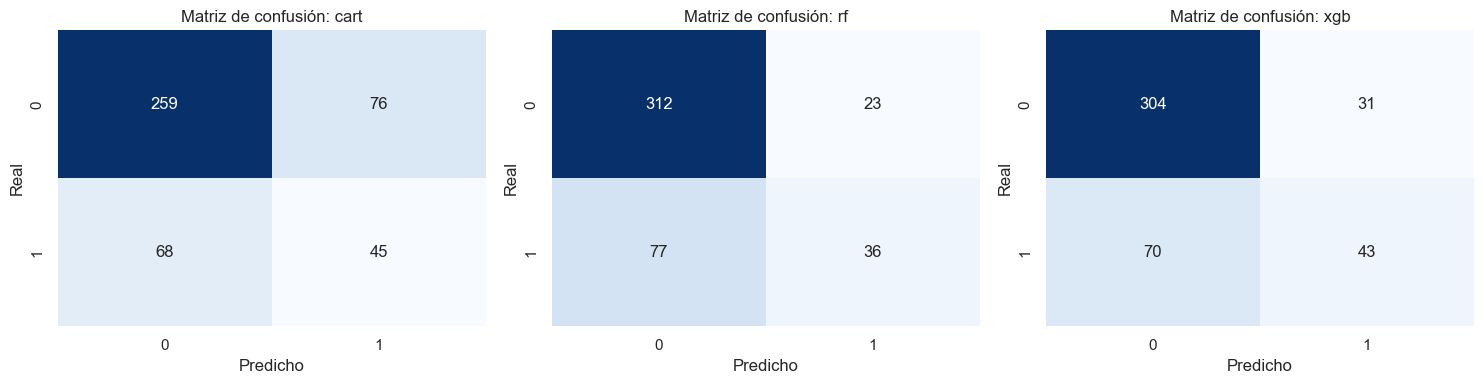

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model_name in zip(axes, ["cart", "rf", "xgb"]):
    cm = base_confusions[model_name]
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de confusión: {model_name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [133]:

c_fn = 3800
c_fp = 1350


# Diccionario con matrices de confusión
conf_matrices = {
    "xgb": {"TN": 320, "FP": 22, "FN": 66, "TP": 40},
    "rf": {"TN": 336, "FP": 6,  "FN": 77, "TP": 29},
    "cart": {"TN": 294, "FP": 48, "FN": 68, "TP": 38}
}

# Función costo
def calcular_costo(model_name):
    cm = conf_matrices[model_name]
    return (
        cm["FN"] * c_fn +
        cm["FP"] * c_fp 
    )

# Añadir columnas nuevas
base_results_df["costo_total"] = base_results_df["model"].apply(calcular_costo)
base_results_df

,accuracy,precision,recall,f2,roc_auc,model,costo_total
0,0.774554,0.581081,0.380531,0.408745,0.769674,xgb,280500
1,0.774554,0.581081,0.380531,0.408745,0.769674,xgb,280500
2,0.678571,0.371901,0.398230,0.392670,0.585682,cart,323200
3,0.678571,0.371901,0.398230,0.392670,0.585682,cart,323200
4,0.776786,0.610169,0.318584,0.352250,0.777440,rf,300700
5,0.776786,0.610169,0.318584,0.352250,0.777440,rf,300700


In [134]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

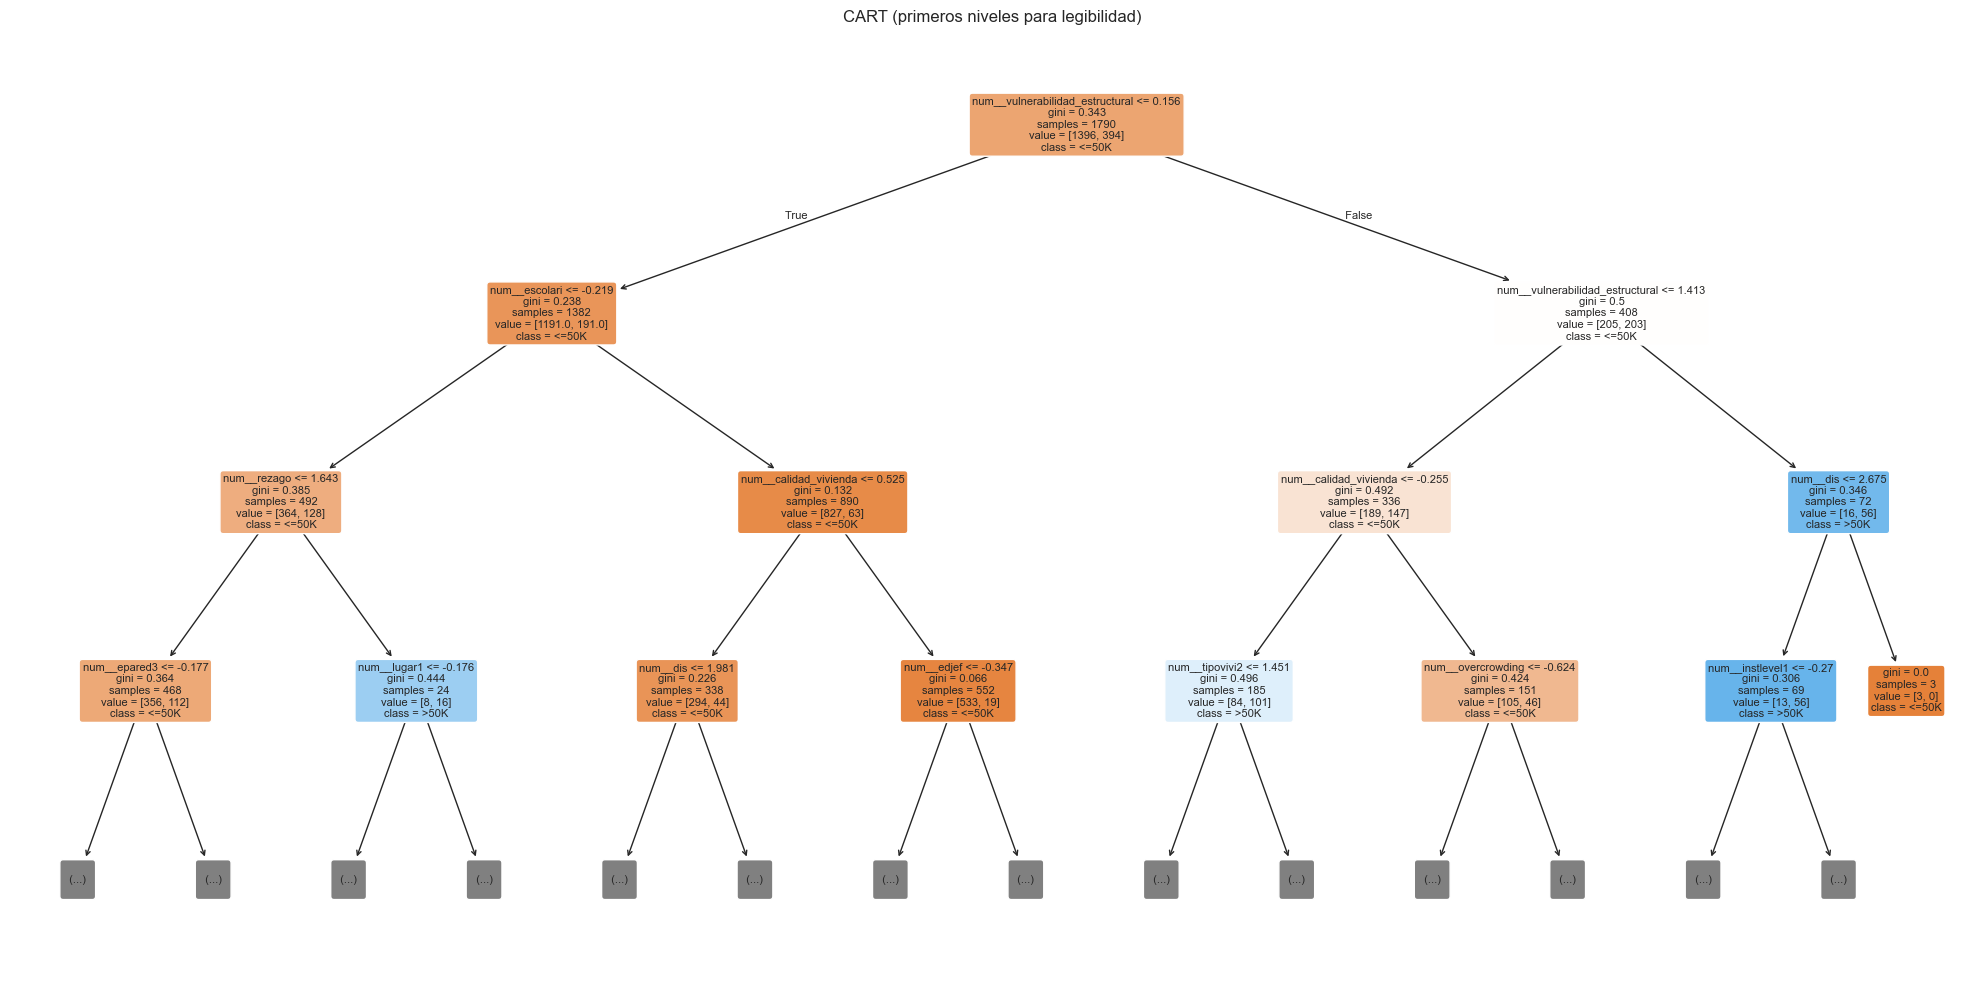

In [135]:
cart_pipe = fitted_base_models["cart"]
cart_model = cart_pipe.named_steps["model"]
feature_names = cart_pipe.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    cart_model,
    max_depth=3,
    feature_names=feature_names,
    class_names=["<=50K", ">50K"],
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("CART (primeros niveles para legibilidad)")
plt.tight_layout()
plt.show()

In [136]:
cart_pipe_grid = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

cart_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 10, 30],
    "model__min_samples_leaf": [1, 5, 15],
    "model__ccp_alpha": [0.0, 0.001, 0.005],
}

grid_cart = GridSearchCV(
    estimator=cart_pipe_grid,
    param_grid=cart_grid,
    scoring=SCORING_MAIN,
    cv=5,
    n_jobs=-1,
    refit=True,
)
grid_cart.fit(X_train, y_train)

# 8.2 RandomizedSearch para RF
rf_pipe_random = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_distributions = {
    "model__n_estimators": [200, 400, 600, 900],
    "model__max_depth": [None, 8, 12, 16, 22],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.4, 0.7],
}

random_rf = RandomizedSearchCV(
    estimator=rf_pipe_random,
    param_distributions=rf_distributions,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING_MAIN,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
random_rf.fit(X_train, y_train)

# 8.3 RandomizedSearch para XGBoost
xgb_pipe_random = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_distributions = {
    "model__n_estimators": [200, 350, 500, 700],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.75, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 8],
    "model__gamma": [0.0, 0.1, 0.3],
    "model__reg_lambda": [0.5, 1.0, 2.0],
}

random_xgb = RandomizedSearchCV(
    estimator=xgb_pipe_random,
    param_distributions=xgb_distributions,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring=SCORING_MAIN,
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
random_xgb.fit(X_train, y_train)

print("Tuning finalizado.")

Tuning finalizado.


In [137]:
X_test

,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,r4h2,r4h3,...,v2a1_reg,rezago,gran_rezago,edjef,hacinamiento_critico,dependencia_ajustada,calidad_vivienda,densidad_tecnologica,vulnerabilidad_estructural,prop_mujeres
134,0.0,4.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.500000,0.0,13.0,0,0.500000,3.0,3.0,0.035714,0.333333
1583,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.400000,0.0,6.0,0,1.000000,2.0,2.0,0.454545,0.133333
187,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,...,0.0,0.000000,0.0,7.0,0,0.750000,1.0,2.0,0.075000,0.100000
296,0.0,5.0,0.0,1.0,1.0,1.0,5.0,1.0,1.0,2.0,...,0.0,0.250000,0.0,17.0,0,0.666667,3.0,3.0,0.055556,0.100000
854,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.000000,0.0,11.0,0,0.333333,3.0,2.0,0.035088,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,0.0,4.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.333333,0.0,7.0,0,0.333333,3.0,2.0,0.074074,0.166667
1829,0.0,5.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,2.0,...,0.0,0.250000,0.0,7.0,0,0.250000,3.0,3.0,0.035714,0.100000
426,0.0,4.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,...,0.0,0.250000,0.0,0.0,0,0.666667,2.0,2.0,0.333333,0.100000
1346,0.0,5.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,...,0.0,0.166667,0.0,9.0,0,1.333333,0.0,2.0,0.296296,0.095238


In [138]:
search_objects = {
    "cart_grid": grid_cart,
    "rf_random": random_rf,
    "xgb_random": random_xgb,
}

tuning_results = []
best_estimators = {}

for search_name, search_obj in search_objects.items():
    best_pipe = search_obj.best_estimator_
    y_prob = best_pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    m = evaluate_model(y_test, y_pred, y_prob)
    m.update({
        "search": search_name,
        "best_cv_f1": search_obj.best_score_,
        "best_params": search_obj.best_params_,
    })
    tuning_results.append(m)
    best_estimators[search_name] = best_pipe

tuning_results_df = pd.DataFrame(tuning_results).sort_values(SCORING_MAIN_NAME, ascending=False).reset_index(drop=True)

print("Resultados tuned (ordenados por F2 en test):")
display(tuning_results_df[["search", "best_cv_f1", "accuracy", "precision", "recall", SCORING_MAIN_NAME, "roc_auc"]])

print("Mejores hiperparámetros por búsqueda:")
for _, row in tuning_results_df.iterrows():
    print(f"- {row['search']}: {row['best_params']}")

Resultados tuned (ordenados por F2 en test):


,search,best_cv_f1,accuracy,precision,recall,f2,roc_auc
0,xgb_random,0.817534,0.792411,0.647059,0.389381,0.423077,0.779976
1,cart_grid,0.790453,0.774554,0.583333,0.371681,0.400763,0.739268
2,rf_random,0.813465,0.770089,0.578125,0.327434,0.358527,0.769806


Mejores hiperparámetros por búsqueda:
- xgb_random: {'model__subsample': 0.8, 'model__reg_lambda': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0.0, 'model__colsample_bytree': 0.6}
- cart_grid: {'model__ccp_alpha': 0.0, 'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
- rf_random: {'model__n_estimators': 900, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.4, 'model__max_depth': 16}


In [151]:
y_prob_train = grid_cart.best_estimator_.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.01)

best_thresh = 0.5
best_f2 = 0

for t in thresholds:
    y_pred_t = (y_prob_train >= t).astype(int)
    f2 = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2 = f2
        best_thresh = t

print(f"Mejor umbral: {best_thresh:.2f} → F2: {best_f2:.4f}")

Mejor umbral: 0.10 → F2: 0.6627


In [152]:
pipe_cart = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

pipe_rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE))
])

pipe_xgb = Pipeline([
    ("preprocess", preprocess),
    ("model", XGBClassifier(scale_pos_weight=4, random_state=RANDOM_STATE))  # ~(342/106)
])

In [156]:
param_grids_f2 = {
    'cart': {
        'model__max_depth':         [3, 5, 8, 10, 15],
        'model__min_samples_leaf':  [1, 3, 5, 10],      # valores más bajos → más recall
        'model__min_samples_split': [2, 5],
        'model__criterion':         ['gini', 'entropy'],
        'model__ccp_alpha':         [0.0, 0.0001, 0.001], # menos poda → más recall
    },
    'rf': {
        'model__n_estimators':      [200, 400, 600],
        'model__max_depth':         [5, 10, 15, None],
        'model__min_samples_leaf':  [1, 3, 5],
        'model__max_features':      [0.3, 0.5, 0.7],
        'model__class_weight':      ['balanced', 'balanced_subsample'],
    },
    'xgb': {
        'model__n_estimators':      [200, 350, 500],
        'model__learning_rate':     [0.01, 0.05, 0.1],
        'model__max_depth':         [3, 4, 6],
        'model__scale_pos_weight':  [3, 4, 5],  # ← clave para F2
        'model__subsample':         [0.7, 0.9],
        'model__colsample_bytree':  [0.6, 0.8],
    }
}

In [157]:
for search_name, search_obj in search_objects.items():
    best_pipe = search_obj.best_estimator_
    y_prob = best_pipe.predict_proba(X_test)[:, 1]
    
    # Buscar umbral óptimo por F2
    best_t, best_f2 = 0.5, 0
    for t in np.arange(0.1, 0.9, 0.01):
        yp = (y_prob >= t).astype(int)
        f2 = fbeta_score(y_test, yp, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    
    y_pred = (y_prob >= best_t).astype(int)
    m = evaluate_model(y_test, y_pred, y_prob)
    m.update({
        "search":      search_name,
        "best_cv_f2":  search_obj.best_score_,
        "best_thresh": best_t,
        "best_params": search_obj.best_params_,
    })


In [160]:
print("Resultados finales:")
display(tuning_results_df[["search", "best_cv_f1", "accuracy", 
                            "precision", "recall", "f2", "roc_auc"]])

Resultados finales:


,search,best_cv_f1,accuracy,precision,recall,f2,roc_auc
0,xgb_random,0.817534,0.792411,0.647059,0.389381,0.423077,0.779976
1,cart_grid,0.790453,0.774554,0.583333,0.371681,0.400763,0.739268
2,rf_random,0.813465,0.770089,0.578125,0.327434,0.358527,0.769806


In [159]:
print(tuning_results_df.columns.tolist())

['accuracy', 'precision', 'recall', 'f2', 'roc_auc', 'search', 'best_cv_f1', 'best_params']


In [167]:
for i, row in tuning_results_df.iterrows():
    best_pipe = best_estimators[row["search"]]
    y_prob    = best_pipe.predict_proba(X_test)[:, 1]
    
    best_t_f2,   best_f2   = 0.5, 0
    best_t_cost, best_cost = 0.5, np.inf

    for t in np.arange(0.1, 0.9, 0.01):
        yp = (y_prob >= t).astype(int)
        
        # F2 óptimo
        f2 = fbeta_score(y_test, yp, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t_f2 = f2, t
        
        # Costo mínimo
        cm = confusion_matrix(y_test, yp)
        tn, fp, fn, tp = cm.ravel()
        costo = (fp * c_fp) + (fn * c_fn)
        if costo < best_cost:
            best_cost, best_t_cost = costo, t

    tuning_results_df.loc[i, 'f2_optimo']   = best_f2
    tuning_results_df.loc[i, 'thresh_f2']   = best_t_f2
    tuning_results_df.loc[i, 'costo_min']   = best_cost
    tuning_results_df.loc[i, 'thresh_cost'] = best_t_cost

print("Resultados con umbral óptimo:")
display(tuning_results_df[["search", "best_cv_f1", "f2", "f2_optimo", 
                            "thresh_f2", "costo_min", "thresh_cost", "roc_auc"]])

Resultados con umbral óptimo:


,search,best_cv_f1,f2,f2_optimo,thresh_f2,costo_min,thresh_cost,roc_auc
0,xgb_random,0.817534,0.423077,0.671965,0.10,247300.0,0.15,0.779976
1,cart_grid,0.790453,0.400763,0.662730,0.10,282400.0,0.14,0.739268
2,rf_random,0.813465,0.358527,0.700000,0.14,246600.0,0.17,0.769806


In [168]:
tuning_results_df = tuning_results_df.sort_values('f2_optimo', ascending=False).reset_index(drop=True)

print("Resultados ordenados por F2 óptimo:")
display(tuning_results_df[["search", "best_cv_f1", "f2", "f2_optimo", 
                            "thresh_f2", "costo_min", "thresh_cost", "roc_auc"]])

print(f"\nMejor modelo: {tuning_results_df.iloc[0]['search']}")
print(f"F2 óptimo:    {tuning_results_df.iloc[0]['f2_optimo']:.4f}")
print(f"Umbral F2:    {tuning_results_df.iloc[0]['thresh_f2']:.2f}")
print(f"Costo mín:    {tuning_results_df.iloc[0]['costo_min']:.0f}")

Resultados ordenados por F2 óptimo:


,search,best_cv_f1,f2,f2_optimo,thresh_f2,costo_min,thresh_cost,roc_auc
0,rf_random,0.813465,0.358527,0.700000,0.14,246600.0,0.17,0.769806
1,xgb_random,0.817534,0.423077,0.671965,0.10,247300.0,0.15,0.779976
2,cart_grid,0.790453,0.400763,0.662730,0.10,282400.0,0.14,0.739268



Mejor modelo: rf_random
F2 óptimo:    0.7000
Umbral F2:    0.14
Costo mín:    246600


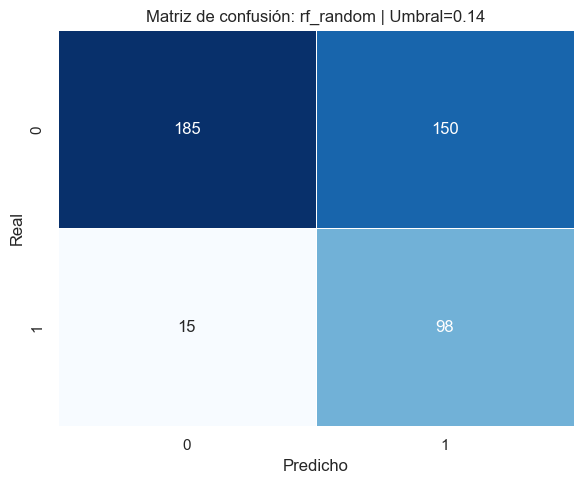

Modelo:    rf_random
Umbral:    0.14
F2:        0.7000
Recall:    0.8673
Precision: 0.3952
Costo:     259500


In [169]:
best_row         = tuning_results_df.iloc[0]
best_search_name = best_row["search"]
best_pipe        = best_estimators[best_search_name]
best_thresh      = best_row["thresh_f2"]

# Predicciones con umbral óptimo
y_prob_opt = best_pipe.predict_proba(X_test)[:, 1]
y_pred_opt = (y_prob_opt >= best_thresh).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1'],
    linewidths=0.5,
    cbar=False
)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title(f'Matriz de confusión: {best_search_name} | Umbral={best_thresh:.2f}')
plt.tight_layout()
plt.show()

# Métricas
tn, fp, fn, tp = cm.ravel()
print(f"Modelo:    {best_search_name}")
print(f"Umbral:    {best_thresh:.2f}")
print(f"F2:        {fbeta_score(y_test, y_pred_opt, beta=2, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}")
print(f"Costo:     {(fp * c_fp) + (fn * c_fn):.0f}")

In [ ]:


# Grid de hiperparámetros
param_grid_costo = {
    'max_depth':         [3, 5, 8, 10],
    'min_samples_leaf':  [1, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'criterion':         ['gini', 'entropy'],
    'ccp_alpha':         [0.0, 0.001, 0.005],
}

mejor_costo = np.inf
mejores_params = None
mejores_thresh = 0.5
resultados_costo = []

for params in ParameterGrid(param_grid_costo):
    # Entrenar
    pipe_temp = Pipeline([
        ("preprocess", best_preprocess),
        ("model", DecisionTreeClassifier(**params, random_state=RANDOM_STATE, class_weight='balanced'))
    ])
    pipe_temp.fit(X_train, y_train)
    y_prob = pipe_temp.predict_proba(X_test)[:, 1]

    # Buscar umbral que minimiza costo
    for t in np.arange(0.1, 0.9, 0.01):
        y_pred_t = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_test, y_pred_t)
        tn, fp, fn, tp = cm.ravel()
        
        costo = (fp * c_fp) + (fn * c_fn)
        
        if costo < mejor_costo:
            mejor_costo    = costo
            mejores_params = params
            mejores_thresh = t
            mejor_tp, mejor_fp, mejor_fn, mejor_tn = tp, fp, fn, tn

resultados_costo.append({
    'params':    mejores_params,
    'threshold': mejores_thresh,
    'costo':     mejor_costo,
    'tp': mejor_tp, 'fp': mejor_fp,
    'fn': mejor_fn, 'tn': mejor_tn,
    'f2': fbeta_score(y_test, 
                      (pipe_temp.predict_proba(X_test)[:, 1] >= mejores_thresh).astype(int), 
                      beta=2, zero_division=0)
})

print(f"Mejor costo total: {mejor_costo}")
print(f"Mejores parámetros: {mejores_params}")
print(f"Umbral óptimo: {mejores_thresh:.2f}")
print(f"TP: {mejor_tp} | FP: {mejor_fp} | FN: {mejor_fn} | TN: {mejor_tn}")

Mejor costo total: 252250
Mejores parámetros: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 10}
Umbral óptimo: 0.72
TP: 69 | FP: 63 | FN: 44 | TN: 272


## Interpretabilidad 
(Graficas visibles en las salidas)

Como se observa en el análisis SHAP, las variables más importantes son la vulnerabilidad estructural, seguida de los años de escolaridad y el cuadrado de este valor. Lo sigue la calidad de la vivienda y las variables relacionadas a esta, y sigue así sucesivamente. 

En el caso de un hogar correctamente clasificado, se observa que la variable con mayor impacto en la predicción es la vulnerabilidad estructural. Esta variable contribuye de manera decisiva a que el hogar sea clasificado como pobre, ya que su indicador de vulnerabilidad es el principal determinante de dicha clasificación, en gran medida debido a la forma en que fue construido este indicador. Y por el comportamiento de estas variables vemos que supera el threshold y lo clasifica debidamente como pobre.

En el caso de un falso negativo, se observa que las características del hogar llevan al modelo a clasificarlo como no pobre. En particular, variables como la escolaridad y la calidad de la vivienda influyen de manera importante en esta decisión, ya que sugieren condiciones de bienestar relativamente favorables. Como resultado, estos factores llevan al modelo a clasificar el hogar como no pobre, a pesar de que en realidad sí lo es.

En el caso del falso positivo, se observa que la escolaridad es la variable que más incrementa la probabilidad de que el hogar sea clasificado como pobre, aunque las características de la vivienda sugieran lo contrario. Además, el umbral (threshold) relativamente bajo contribuye a que este hogar sea clasificado como pobre. No obstante, este umbral se establece de esta manera para priorizar la reducción de falsos negativos, es decir, evitar que hogares pobres sean clasificados erróneamente como no pobres. 

Si un funcionario pregunta, la mejor explicación es que el hogar es educado y además cuenta con una buena vivienda, siendo estos los factores más importantes. 

Modelo: rf_random
Shape SHAP: (448, 146)


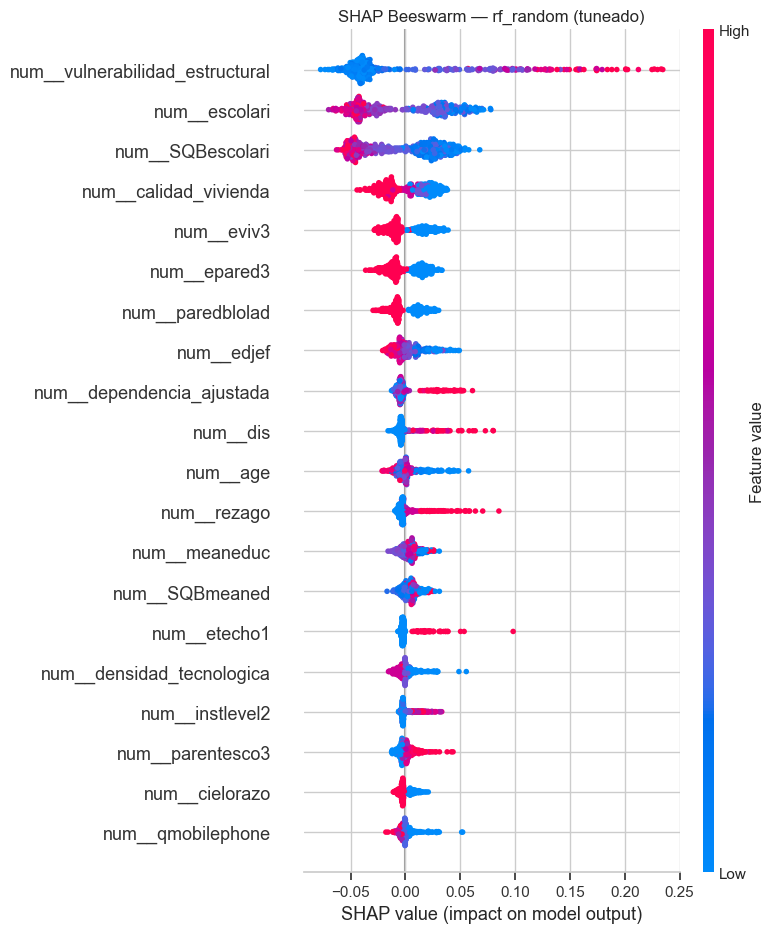


Top 10 variables por impacto SHAP:
num__vulnerabilidad_estructural    0.056438
num__escolari                      0.038509
num__SQBescolari                   0.031689
num__calidad_vivienda              0.018010
num__eviv3                         0.014639
num__epared3                       0.013875
num__paredblolad                   0.011729
num__edjef                         0.009033
num__dependencia_ajustada          0.008374
num__dis                           0.007309
dtype: float64


In [170]:
best_model      = best_pipe.named_steps["model"]
best_preprocess = best_pipe.named_steps["preprocess"]

# 2. Transformar X_test
X_test_proc = best_preprocess.transform(X_test)
if sparse.issparse(X_test_proc):
    X_test_proc = X_test_proc.toarray()

feature_names = best_preprocess.get_feature_names_out()

# 3. Submuestra para acelerar
n_shap   = min(1500, X_test_proc.shape[0])
idx_eval = np.random.RandomState(RANDOM_STATE).choice(X_test_proc.shape[0], size=n_shap, replace=False)
X_eval_proc = X_test_proc[idx_eval]

# 4. Calcular SHAP
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_eval_proc)

# 5. Extraer clase 1
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_class1 = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    shap_class1 = shap_values[1]
    expected_value = explainer.expected_value[1]
else:
    shap_class1    = shap_values
    expected_value = explainer.expected_value

print(f"Modelo: {best_search_name}")
print(f"Shape SHAP: {shap_class1.shape}")

# 6. Beeswarm top 20
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_class1,
    X_eval_proc,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title(f"SHAP Beeswarm — {best_search_name} (tuneado)")
plt.tight_layout()
plt.show()

# 7. Variable con mayor impacto
top_shap = pd.Series(
    np.abs(shap_class1).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print("\nTop 10 variables por impacto SHAP:")
print(top_shap.head(10))

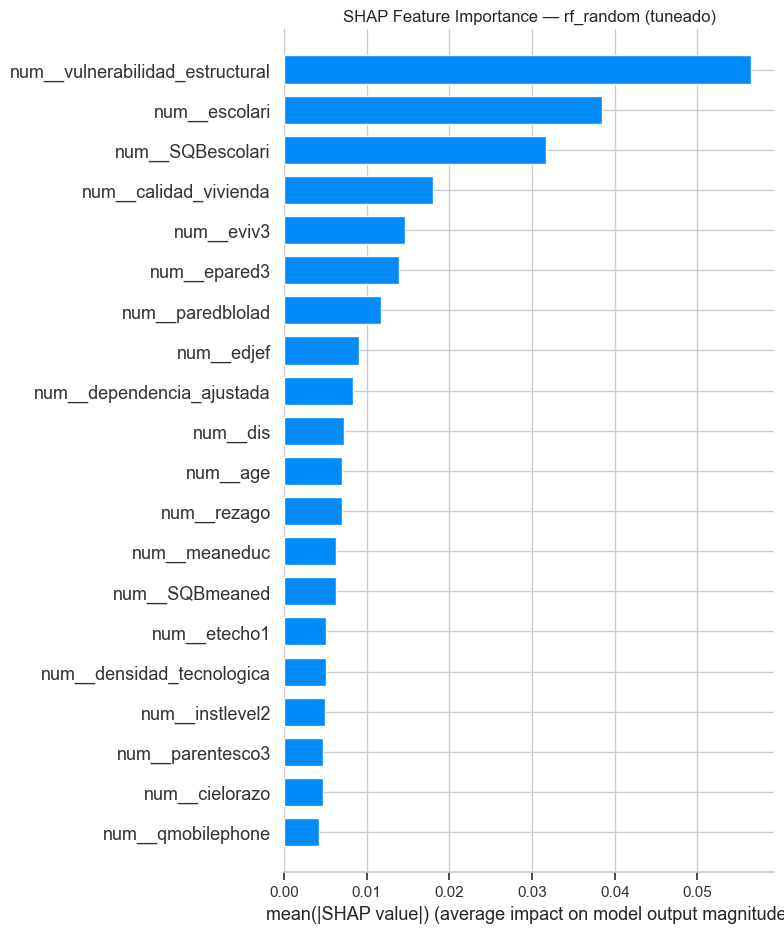

In [171]:
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_class1,
    X_eval_proc,
    feature_names=feature_names,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(f"SHAP Feature Importance — {best_search_name} (tuneado)")
plt.tight_layout()
plt.show()

Verdadero Positivo — índice: 1
Falso Negativo     — índice: 4
Falso Positivo     — índice: 5


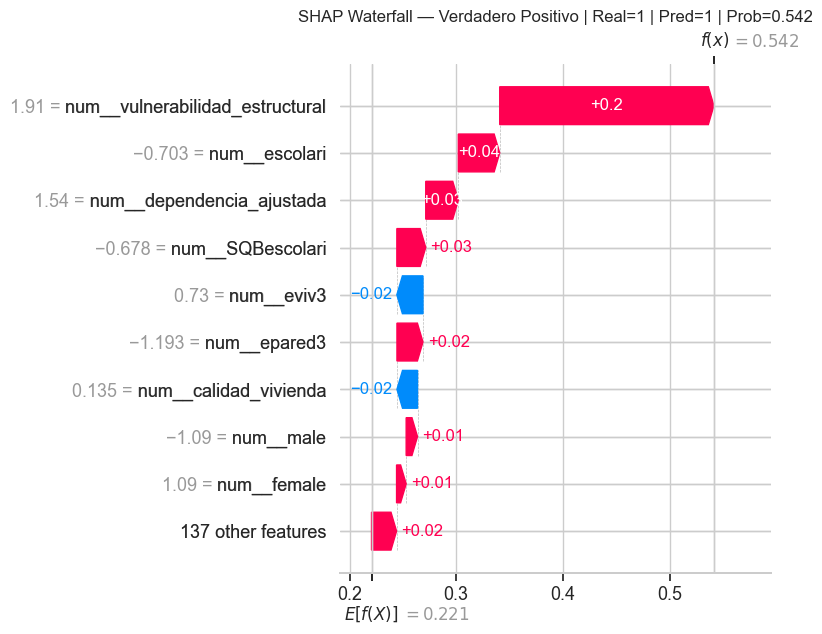


Top 5 variables — Verdadero Positivo:
  num__vulnerabilidad_estructural: 0.2008 → POBRE
  num__escolari: 0.0388 → POBRE
  num__dependencia_ajustada: 0.0305 → POBRE
  num__SQBescolari: 0.0271 → POBRE
  num__eviv3: -0.0245 → NO POBRE



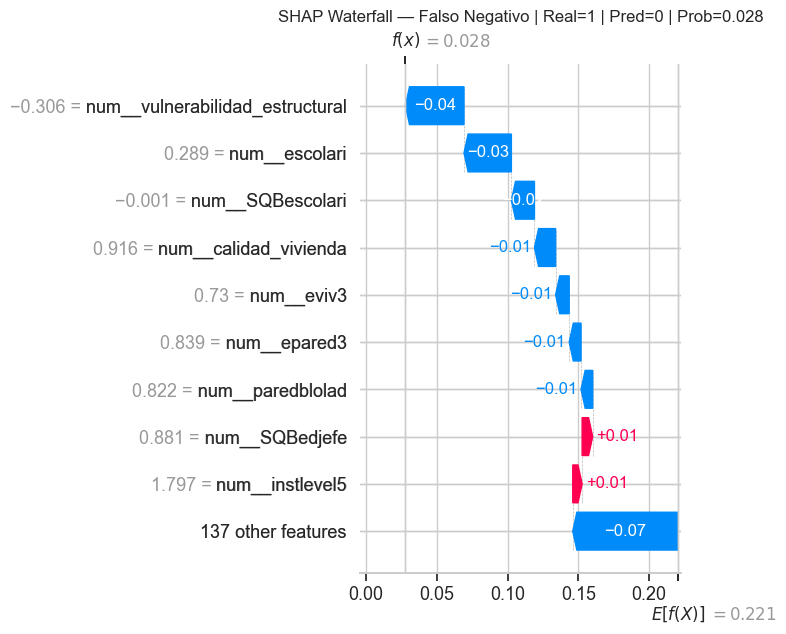


Top 5 variables — Falso Negativo:
  num__vulnerabilidad_estructural: -0.0414 → NO POBRE
  num__escolari: -0.0335 → NO POBRE
  num__SQBescolari: -0.0163 → NO POBRE
  num__calidad_vivienda: -0.0149 → NO POBRE
  num__eviv3: -0.0096 → NO POBRE



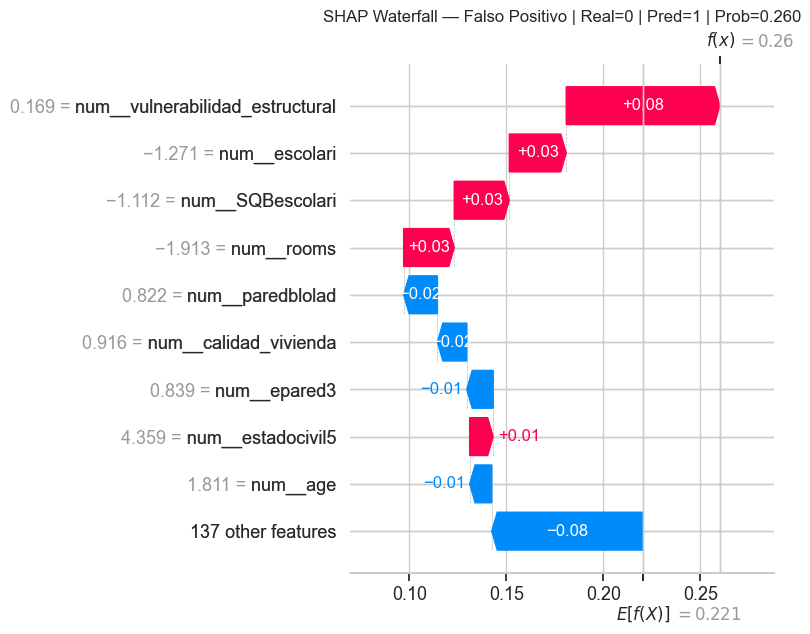


Top 5 variables — Falso Positivo:
  num__vulnerabilidad_estructural: 0.0792 → POBRE
  num__escolari: 0.0293 → POBRE
  num__SQBescolari: 0.0284 → POBRE
  num__rooms: 0.0261 → POBRE
  num__paredblolad: -0.0174 → NO POBRE



In [173]:

y_prob_test = best_pipe.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_thresh).astype(int)
y_test_arr  = y_test.values

# 2. Identificar los 3 hogares
vp_idx = np.where((y_pred_test == 1) & (y_test_arr == 1))[0][0]
fn_idx = np.where((y_pred_test == 0) & (y_test_arr == 1))[0][0]
fp_idx = np.where((y_pred_test == 1) & (y_test_arr == 0))[0][0]

print(f"Verdadero Positivo — índice: {vp_idx}")
print(f"Falso Negativo     — índice: {fn_idx}")
print(f"Falso Positivo     — índice: {fp_idx}")

# 3. Calcular SHAP para los 3 hogares
hogares_proc = X_test_proc[[vp_idx, fn_idx, fp_idx]]
shap_hogares = explainer.shap_values(hogares_proc)

if isinstance(shap_hogares, np.ndarray) and shap_hogares.ndim == 3:
    shap_hogares_c1 = shap_hogares[:, :, 1]
    ev = explainer.expected_value[1]
elif isinstance(shap_hogares, list):
    shap_hogares_c1 = shap_hogares[1]
    ev = explainer.expected_value[1]
else:
    shap_hogares_c1 = shap_hogares
    ev = explainer.expected_value

# 4. Waterfall para cada hogar
etiquetas = ['Verdadero Positivo', 'Falso Negativo', 'Falso Positivo']

for i, etiqueta in enumerate(etiquetas):
    idx  = [vp_idx, fn_idx, fp_idx][i]
    real = y_test_arr[idx]
    pred = y_pred_test[idx]
    prob = y_prob_test[idx]

    shap_exp = shap.Explanation(
        values        = shap_hogares_c1[i],
        base_values   = ev,
        data          = hogares_proc[i],
        feature_names = feature_names
    )

    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.title(f"SHAP Waterfall — {etiqueta} | Real={real} | Pred={pred} | Prob={prob:.3f}")
    plt.tight_layout()
    plt.show()

    # Top 5 variables que empujaron la decisión
    top_push = pd.Series(
        shap_hogares_c1[i],
        index=feature_names
    ).sort_values(key=abs, ascending=False).head(5)

    print(f"\nTop 5 variables — {etiqueta}:")
    for var, val in top_push.items():
        direccion = "→ POBRE" if val > 0 else "→ NO POBRE"
        print(f"  {var}: {val:.4f} {direccion}")
    print()

## Exportación modelo

In [175]:
joblib.dump(best_pipe, f'modelo_{best_search_name}.pkl')
print(f"Modelo exportado con joblib: modelo_{best_search_name}.pkl")

Modelo exportado con joblib: modelo_rf_random.pkl


In [176]:
modelo_cargado = joblib.load(f'modelo_{best_search_name}.pkl')
y_prob_verificacion = modelo_cargado.predict_proba(X_test)[:, 1]
y_pred_verificacion = (y_prob_verificacion >= best_thresh).astype(int)

print(f"\nVerificación modelo cargado:")
print(f"  F2:    {fbeta_score(y_test, y_pred_verificacion, beta=2, zero_division=0):.4f}")
print(f"  Costo: {(confusion_matrix(y_test, y_pred_verificacion).ravel()[1] * c_fp) + (confusion_matrix(y_test, y_pred_verificacion).ravel()[2] * c_fn):.0f}")


Verificación modelo cargado:
  F2:    0.7000
  Costo: 259500
